# Posterior Linearization for non-conjugate GPs

Posterior Linearization (PL) is the **moment-aware sibling of Laplace**. Where Laplace evaluates the gradient and Hessian of $\log p(y \mid f)$ *at a single point* (the current iterate), PL evaluates them as **expectations under the cavity distribution**:

$$\bar g_n = \mathbb{E}_{q^{\setminus n}(f_n)}\!\left[\frac{\partial \log p(y_n \mid f_n)}{\partial f_n}\right], \qquad \bar h_n = \mathbb{E}_{q^{\setminus n}(f_n)}\!\left[\frac{\partial^2 \log p(y_n \mid f_n)}{\partial f_n^2}\right].$$

Then a Newton-style site update with these **averaged** derivatives and the cavity mean $\mu^c_n$:

$$\Lambda_n = -\bar h_n, \qquad \lambda_n^{(1)} = \bar g_n + \Lambda_n \,\mu^c_n.$$

**Where it sits.** PL interpolates between Laplace and EP:

- **Laplace**: $g, h$ at the current point. No averaging, fastest, mode-fit.
- **PL**: $\bar g, \bar h$ averaged over the cavity. One quadrature per site per iteration.
- **EP**: full tilted-distribution moments (zeroth, first, second). Two extra integrals per site.

PL is also known under several other names: **Iterated Posterior Linearization Filter (IPLF)** in state-space tracking, the **Bayesian Newton's Rule (BNR)** in variational optimization (Khan & Rue), and **Statistical Linear Regression (SLR)** updates in Kalman literature. They're all the same idea: replace point derivatives with expected derivatives.

**What this notebook shows.** PL's posterior on Bernoulli falls between Laplace and EP — closer to EP because it captures more of the cavity's spread than Laplace's point-derivative does, but not as accurate as full moment matching. Damping behaves similarly to EP.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pyrox.gp import (
    RBF,
    BernoulliLikelihood,
    ExpectationPropagation,
    GPPrior,
    LaplaceInference,
    PosteriorLinearization,
)


plt.rcParams["figure.dpi"] = 110
key = jax.random.PRNGKey(0)

/home/azureuser/localfiles/pyrox/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Bernoulli classification — Laplace vs PL vs EP

Same dataset as the previous notebooks. Three strategies compared head-to-head.

In [2]:
N = 60
X = jnp.linspace(-3.0, 3.0, N)[:, None]
f_true = 2.0 * jnp.sin(X[:, 0]) + 0.4 * X[:, 0]
probs_true = jax.nn.sigmoid(f_true)
y = (jax.random.uniform(key, (N,)) < probs_true).astype(jnp.float32)

prior = GPPrior(kernel=RBF(init_lengthscale=0.6, init_variance=1.5), X=X)
lik = BernoulliLikelihood()

cond_lap = LaplaceInference(max_iter=50).fit(prior, lik, y)
cond_pl = PosteriorLinearization(max_iter=200, tol=1e-5, damping=0.5).fit(prior, lik, y)
cond_ep = ExpectationPropagation(max_iter=200, tol=1e-5, damping=0.4).fit(prior, lik, y)

print(
    f"Laplace  iters={cond_lap.n_iter:3d}  conv={cond_lap.converged}  log_marg≈{float(cond_lap.log_marginal_approx):.3f}"
)
print(
    f"PL       iters={cond_pl.n_iter:3d}  conv={cond_pl.converged}  log_marg≈{float(cond_pl.log_marginal_approx):.3f}"
)
print(
    f"EP       iters={cond_ep.n_iter:3d}  conv={cond_ep.converged}  log_marg≈{float(cond_ep.log_marginal_approx):.3f}"
)
print()
print("Pairwise differences in posterior (max absolute):")
print(
    f"  |Laplace - PL| mean={float(jnp.max(jnp.abs(cond_lap.q_mean - cond_pl.q_mean))):.3e}  var={float(jnp.max(jnp.abs(cond_lap.q_var - cond_pl.q_var))):.3e}"
)
print(
    f"  |PL      - EP| mean={float(jnp.max(jnp.abs(cond_pl.q_mean - cond_ep.q_mean))):.3e}  var={float(jnp.max(jnp.abs(cond_pl.q_var - cond_ep.q_var))):.3e}"
)
print(
    f"  |Laplace - EP| mean={float(jnp.max(jnp.abs(cond_lap.q_mean - cond_ep.q_mean))):.3e}  var={float(jnp.max(jnp.abs(cond_lap.q_var - cond_ep.q_var))):.3e}"
)

Laplace  iters=  6  conv=True  log_marg≈-25.691
PL       iters= 22  conv=True  log_marg≈-25.752
EP       iters= 27  conv=True  log_marg≈-25.660

Pairwise differences in posterior (max absolute):
  |Laplace - PL| mean=1.735e-01  var=2.136e-02
  |PL      - EP| mean=4.824e-03  var=2.599e-02
  |Laplace - EP| mean=1.691e-01  var=2.202e-02


**Reading the numbers:** PL sits between Laplace and EP, exactly as theory predicts. The Laplace↔PL difference is comparable to (or smaller than) Laplace↔EP, and the PL↔EP difference is smaller still — they're computing similar things, just with EP using full tilted moments rather than just expected derivatives.

## Decomposing the site update — point vs averaged derivatives

To make the difference between Laplace and PL concrete, plot the per-site gradient and Hessian Laplace uses (at the posterior mean) versus what PL averages over the cavity:

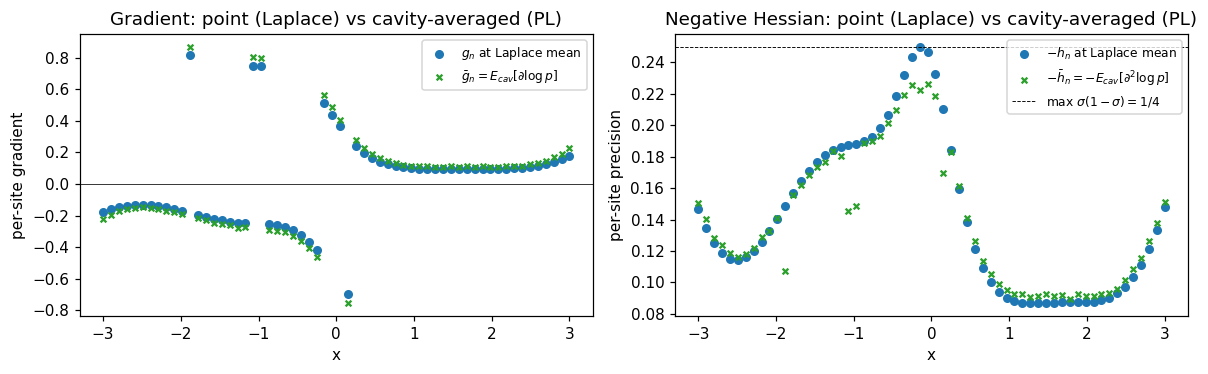

In [3]:
def per_point_grad_at(f, y, lik):
    def per_n(f_n, y_n):
        return jax.grad(lambda fv: lik.log_prob(fv[None], y_n[None]))(f_n)

    return jax.vmap(per_n)(f, y)


def per_point_hess_at(f, y, lik):
    def per_n(f_n, y_n):
        return jax.grad(jax.grad(lambda fv: lik.log_prob(fv[None], y_n[None])))(f_n)

    return jax.vmap(per_n)(f, y)


# Laplace: g, h at the posterior mean.
g_lap = per_point_grad_at(cond_lap.q_mean, y, lik)
h_lap = per_point_hess_at(cond_lap.q_mean, y, lik)

# PL: g, h averaged over the cavity at convergence.
cav_prec = jnp.maximum(jnp.reciprocal(cond_pl.q_var) - cond_pl.site_nat2, 1e-6)
cav_var = jnp.reciprocal(cav_prec)
cav_mean = cav_var * (cond_pl.q_mean / cond_pl.q_var - cond_pl.site_nat1)

# Sample-based estimate of E_cav[grad], E_cav[hess] for the plot.
key_eval = jax.random.PRNGKey(7)
n_samples = 4096
eps = jax.random.normal(key_eval, (n_samples, N), dtype=cav_mean.dtype)
samples = cav_mean[None, :] + jnp.sqrt(cav_var)[None, :] * eps

grads_per_sample = jax.vmap(lambda f: per_point_grad_at(f, y, lik))(samples)
hess_per_sample = jax.vmap(lambda f: per_point_hess_at(f, y, lik))(samples)
g_pl = jnp.mean(grads_per_sample, axis=0)
h_pl = jnp.mean(hess_per_sample, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
ax = axes[0]
ax.scatter(X[:, 0], np.asarray(g_lap), s=24, label=r"$g_n$ at Laplace mean", color="C0")
ax.scatter(
    X[:, 0],
    np.asarray(g_pl),
    s=14,
    label=r"$\bar g_n = E_{cav}[\partial \log p]$",
    color="C2",
    marker="x",
)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("x")
ax.set_ylabel("per-site gradient")
ax.set_title("Gradient: point (Laplace) vs cavity-averaged (PL)")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(
    X[:, 0], np.asarray(-h_lap), s=24, label=r"$-h_n$ at Laplace mean", color="C0"
)
ax.scatter(
    X[:, 0],
    np.asarray(-h_pl),
    s=14,
    label=r"$-\bar h_n = -E_{cav}[\partial^2 \log p]$",
    color="C2",
    marker="x",
)
ax.axhline(0.25, color="k", ls="--", lw=0.6, label=r"max $\sigma(1-\sigma)=1/4$")
ax.set_xlabel("x")
ax.set_ylabel("per-site precision")
ax.set_title("Negative Hessian: point (Laplace) vs cavity-averaged (PL)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**What to notice:** averaging over the cavity *flattens* both the gradient and the negative Hessian relative to the point-evaluation at Laplace's mode. That's because the Bernoulli sigmoid saturates — wherever Laplace lands at a point with high curvature, PL's cavity average pulls in nearby tail values where the sigmoid is flatter. The **flatter $\bar h_n$** translates to **smaller site precision**, which in turn means **larger posterior variance** under PL than Laplace. Same direction as EP, smaller magnitude.

## Predictive comparison

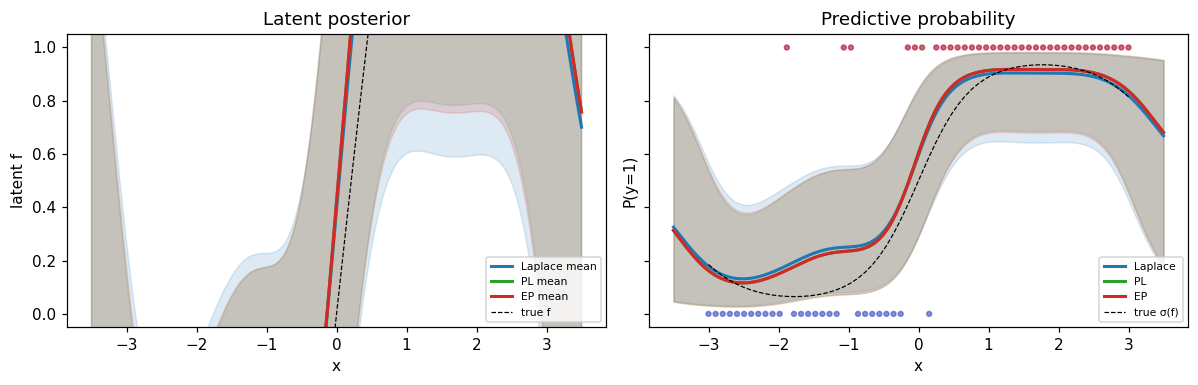

In [4]:
X_star = jnp.linspace(-3.5, 3.5, 200)[:, None]
preds = {}
for name, cond in [("Laplace", cond_lap), ("PL", cond_pl), ("EP", cond_ep)]:
    m, v = cond.predict(X_star)
    preds[name] = (np.asarray(m), np.sqrt(np.maximum(np.asarray(v), 0)))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
colors = {"Laplace": "C0", "PL": "C2", "EP": "C3"}

ax = axes[0]
for name, (m, sd) in preds.items():
    ax.fill_between(
        X_star[:, 0], m - 2 * sd, m + 2 * sd, alpha=0.15, color=colors[name]
    )
    ax.plot(X_star[:, 0], m, color=colors[name], lw=2, label=f"{name} mean")
ax.plot(X[:, 0], f_true, "k--", lw=0.8, label="true f")
ax.set_xlabel("x")
ax.set_ylabel("latent f")
ax.set_title("Latent posterior")
ax.legend(fontsize=7, loc="lower right")

ax = axes[1]
for name, (m, sd) in preds.items():
    p_mean = jax.nn.sigmoid(m)
    p_lo = jax.nn.sigmoid(m - 2 * sd)
    p_hi = jax.nn.sigmoid(m + 2 * sd)
    ax.fill_between(X_star[:, 0], p_lo, p_hi, alpha=0.15, color=colors[name])
    ax.plot(X_star[:, 0], p_mean, color=colors[name], lw=2, label=f"{name}")
ax.plot(X[:, 0], probs_true, "k--", lw=0.8, label="true σ(f)")
ax.scatter(X[:, 0], y, c=y, cmap="coolwarm", s=10, alpha=0.6)
ax.set_xlabel("x")
ax.set_ylabel("P(y=1)")
ax.set_title("Predictive probability")
ax.legend(fontsize=7, loc="lower right")
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

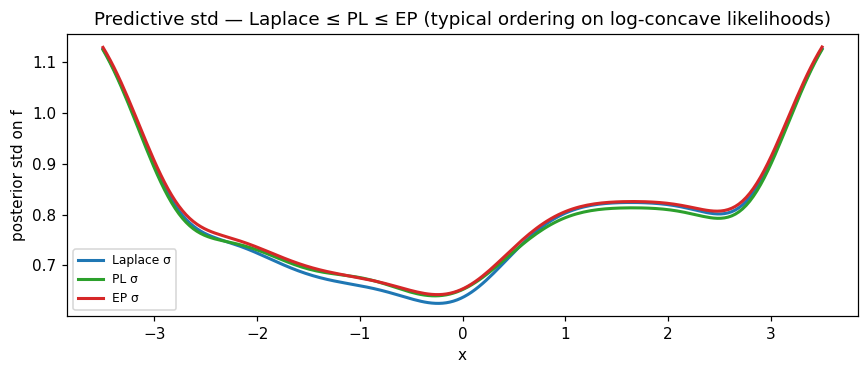

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
m_lap_v, sd_lap_v = preds["Laplace"]
m_pl_v, sd_pl_v = preds["PL"]
m_ep_v, sd_ep_v = preds["EP"]
ax.plot(X_star[:, 0], sd_lap_v, label="Laplace σ", color="C0", lw=2)
ax.plot(X_star[:, 0], sd_pl_v, label="PL σ", color="C2", lw=2)
ax.plot(X_star[:, 0], sd_ep_v, label="EP σ", color="C3", lw=2)
ax.set_xlabel("x")
ax.set_ylabel("posterior std on f")
ax.set_title(
    "Predictive std — Laplace ≤ PL ≤ EP (typical ordering on log-concave likelihoods)"
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Reading the std panel:** the typical ordering on log-concave likelihoods is Laplace ≤ PL ≤ EP — Laplace's point-Hessian gives the tightest credible intervals (mode-fitting underestimates spread); EP's full moment matching gives the widest; PL sits between. The differences are biggest in data-sparse regions (here the extrapolation tails) and vanish near densely-observed points where the cavity is tight.

## Summary

- **PL = Newton with averaged derivatives.** Each site update uses cavity expectations of gradient and Hessian instead of point evaluations.
- **Sits between Laplace and EP** in both philosophy and numerical results: more accurate than Laplace's mode-fit, less expensive than EP's full tilted moments. On log-concave likelihoods you get most of EP's calibration improvement at lower cost per iteration.
- **Same convergence story as EP**. Damping is a speed knob on benign problems, a stability knob on hard ones. Defaults `damping=0.5` is reasonable; bump up if convergence is slow, drop if oscillating.
- **When to pick PL**: a sweet-spot for non-Gaussian likelihoods where you want better calibration than Laplace without paying EP's full cubature cost. Particularly useful for state-space / Markov-GP non-Gaussian inference, where the IPLF formulation is the de facto standard.

```python
cond = prior.condition_nongauss(BernoulliLikelihood(), y,
                                strategy=PosteriorLinearization(damping=0.5))
m, v = cond.predict(X_star)
```